## Исследовательский анализ данных заказов в сервисе Яндекс Афиша

### Цель проекта:

Провести предобработку и исследовательский анализ данных о заказах билетов в сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Изучить сезонные изменения спроса, активность пользователей и вклад регионов и партнеров, а также проверить гипотезы о различиях активности пользователей мобильных и стационарных устройств

### Задачи проекта:

1. Загрузить датасеты с заказами, мероприятиями и курсом тенге к рублю.
2. Изучить структуру, объем, типы данных и пропуски.
3. Проверить корректность выгрузки из SQL и качество данных.
4. Обработать пропуски, ошибки, явные и неявные дубликаты.
5. Исследовать распределения выручки и количества билетов в заказе.
6. Обработать выбросы в выручке с использованием 99-го процентиля отдельно для рублей и тенге.
7. Привести выручку к российским рублям.
8. Создать дополнительные признаки: выручку за один билет, месяц заказа и сезон.
9. Подготовить единый датафрейм для дальнейшего исследования.
10. Сформулировать промежуточные выводы.
11. Проанализировать распределение заказов по месяцам и сезонам, типам мероприятий, устройствам и возрастным категориям.
12. Изучить динамику заказов, DAU, среднего числа заказов на пользователя и средней стоимости билета по дням осенью.
13. Исследовать недельную цикличность активности пользователей.
14. Проанализировать вклад регионов и билетных партнеров в количество мероприятий, заказов и выручку.
15. Проверить гипотезы о большей активности пользователей мобильных устройств по сравнению со стационарными.
16. Сформулировать общий вывод и рекомендации для продуктовой команды.
<a id="step1"></a>
### Содержание

##### 1. Загрузка данных и знакомство с ними  
1.1. [Импорт библиотек и загрузка данных](#step2)   
1.2. [Общая информация о датасетах](#step3)   
1.3. [Промежуточный вывод](#step4)   
##### 2. Предобработка и подготовка данных    
2.1. [Проверка пропусков и корректности выгрузки](#step5)   
2.2. [Анализ категориальных значений](#step6)   
2.3. [Анализ количественных значений и выбросов](#step7)   
2.4. [Проверка явных и неявных дубликатов](#step8)   
2.5. [Преобразование типов данных](#step9)   
2.6. [Создание новых признаков](#step10)   
2.7. [Промежуточные выводы](#step11)   
##### 3. Исследовательский анализ данных  
3.1. [Анализ распределения заказов по сегментам и их сезонные изменения](#step12)  
3.2. [Осенняя активность пользователей](#step13)  
3.3. [Популярные события и партнёры](#step14)
##### 4. Статистический анализ данных  
4.1. [Проверка гипотезы о среднем количестве заказов на пользователя](#step15)  
4.2. [Проверка гипотезы о среднем времени между заказами](#step16)  
4.3. [Выводы по проверке гипотез](#step17)
##### 5. [Общий вывод и рекомендации](#step18)


### Описание данных
В исследовании три датасета:

`final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total — общая` сумма заказа.
- `days_since_prev` - количество дней с предыдущей покупки для каждого пользователя, eсли предыдущей покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:
- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

Датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (kzt)

<a id="step2"></a>
### 1. Загрузка данных и знакомство с ними
#### 1.1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

Исходный датасет не публикуется.
Данные предоставлены в рамках учебного проекта Яндекс Практикума.

In [2]:
purchases = pd.read_csv('https://_______________')
events = pd.read_csv('https://_______________')
tenge_rate = pd.read_csv('https://_______________')

[Назад к содержанию](#step1)

<a id="step3"></a>
#### 1.2. Общая информация о датасетах

In [3]:
print('Размер датасета с заказами:', purchases.shape)
print('Размер датасета с мероприятиями:', events.shape)
print('Размер датасета с курсом тенге:', tenge_rate.shape)

Размер датасета с заказами: (290849, 14)
Размер датасета с мероприятиями: (22427, 11)
Размер датасета с курсом тенге: (357, 4)


In [4]:
print('Информация о датасете с заказами')
purchases.info()

print('\nИнформация о датасете с мероприятиями')
events.info()

print('\nИнформация о датасете с курсом тенге')
tenge_rate.info()

Информация о датасете с заказами
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: 

In [5]:
print('Пропуски в датасете с заказами:')
display(purchases.isna().sum())

print('Пропуски в датасете с мероприятиями:')
display(events.isna().sum())

print('Пропуски в датасете с курсом тенге:')
display(tenge_rate.isna().sum())

Пропуски в датасете с заказами:


order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

Пропуски в датасете с мероприятиями:


event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

Пропуски в датасете с курсом тенге:


data       0
nominal    0
curs       0
cdx        0
dtype: int64

In [6]:
display(purchases.head())

display(events.head())

display(tenge_rate.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


[Назад к содержанию](#step1)

<a id="step4"></a>
#### 1.3. Промежуточный вывод

Были загружены три датасета:

- `purchases` — информация о заказах включает 290849 строк и 14 столбцов;
- `events` — информация о мероприятиях включает 22427 строк и 11 столбцов;
- `tenge_rate` — информация о курсе тенге к рублю включает 357 строк и 4 столбца.

Датасет с заказами является основным и содержит информацию об идентификаторах заказов и пользователей, дате и времени заказа, мероприятии, устройстве, валюте, выручке, количестве билетов и общей сумме заказа.

В датасете с мероприятиями содержится информация о названии и типе мероприятия, организаторе, регионе, городе и площадке. В описании данных не был указан столбец `city_id`, однако он присутствует в выгрузке и содержит идентификатор города.

В датасете с курсом тенге содержатся дата, номинал, курс и обозначение валюты. Эти данные потребуются для приведения выручки из тенге к российским рублям.

Пропуски обнаружены только в столбце `days_since_prev` датасета `orders` - 21 940 строк. Это соответствует условию задачи: пропуск означает, что для пользователя нет данных о предыдущей покупке. В остальных столбцах датасетов пропуски отсутствуют, следовательно, выгрузка данных из SQL выглядит корректной.

На этапе предобработки необходимо:

1. Преобразовать столбцы с датой и временем `created_dt_msk`, `created_ts_msk` и `data` в формат даты.
2. Проверить категориальные столбцы на наличие неявных пропусков, ошибок в названиях и дублирующихся категорий.
3. Изучить распределения выручки `revenue` и количества билетов `tickets_count`, а также проверить наличие выбросов отдельно для заказов в рублях и тенге.
4. Проверить явные и неявные дубликаты, в особенности дубликаты бронирований без учёта идентификатора заказа.
5. Привести выручку к единой валюте.
6. Объединить данные о заказах и мероприятиях по столбцу `event_id`.
7. Создать новые столбцы с выручкой в рублях, выручкой за один билет, месяцем заказа и сезоном.

[Назад к содержанию](#step1)

<a id="step5"></a>
### 2. Предобработка и подготовка данных
#### 2.1. Проверка пропусков и корректности выгрузки

In [7]:
print('Пропуски в датасете purchases:')
display(purchases.isna().sum())

print('Пропуски в датасете events:')
display(events.isna().sum())

print('Пропуски в датасете tenge_rate:')
display(tenge_rate.isna().sum())

Пропуски в датасете purchases:


order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

Пропуски в датасете events:


event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

Пропуски в датасете tenge_rate:


data       0
nominal    0
curs       0
cdx        0
dtype: int64

In [8]:
# Проверка корректности выгрузки по датам

print('Минимальная дата заказа:', purchases['created_dt_msk'].min())
print('Максимальная дата заказа:', purchases['created_dt_msk'].max())

Минимальная дата заказа: 2024-06-01
Максимальная дата заказа: 2024-10-31


In [9]:
negative_revenue_count = purchases[purchases['revenue'] < 0].shape[0]

print(
    'Количество заказов с отрицательной выручкой:',
    negative_revenue_count
)

negative_revenue_share = (
    purchases[purchases['revenue'] < 0].shape[0]
    / purchases.shape[0]
    * 100
)

print(
    'Доля заказов с отрицательной выручкой:',
    round(negative_revenue_share, 3),
    '%'
)

Количество заказов с отрицательной выручкой: 381
Доля заказов с отрицательной выручкой: 0.131 %


[Назад к содержанию](#step1)

<a id="step6"></a>
#### 2.2. Анализ категориальных значений

In [10]:
print('Количество уникальных значений в purchases:')
display(purchases[['cinema_circuit','age_limit','currency_code','device_type_canonical','service_name']].nunique())

print('Количество уникальных значений в events:')
display(events[['event_type_description','event_type_main','region_name','city_name']].nunique())

print('Количество уникальных значений в tenge_rate:')
display(tenge_rate['cdx'].nunique())

Количество уникальных значений в purchases:


cinema_circuit            6
age_limit                 5
currency_code             2
device_type_canonical     2
service_name             36
dtype: int64

Количество уникальных значений в events:


event_type_description     20
event_type_main             7
region_name                81
city_name                 352
dtype: int64

Количество уникальных значений в tenge_rate:


1

In [11]:
# Выводим уникальные значения в категориальных столбцах purchases
for column in [
    'cinema_circuit',
    'age_limit',
    'currency_code',
    'device_type_canonical',
    'service_name'
]:
    print(f'Уникальные значения в столбце {column}:')
    print(purchases[column].sort_values().unique())
    print()

Уникальные значения в столбце cinema_circuit:
['Другое' 'КиноСити' 'Киномакс' 'Москино' 'ЦентрФильм' 'нет']

Уникальные значения в столбце age_limit:
[ 0  6 12 16 18]

Уникальные значения в столбце currency_code:
['kzt' 'rub']

Уникальные значения в столбце device_type_canonical:
['desktop' 'mobile']

Уникальные значения в столбце service_name:
['Crazy ticket!' 'Show_ticket' 'Билет по телефону' 'Билеты без проблем'
 'Билеты в интернете' 'Билеты в руки' 'Быстробилет' 'Быстрый кассир'
 'Весь в билетах' 'Восьмёрка' 'Вперёд!' 'Выступления.ру'
 'Городской дом культуры' 'Дом культуры' 'Дырокол' 'За билетом!'
 'Зе Бест!' 'КарандашРУ' 'Кино билет' 'Край билетов' 'Лимоны'
 'Лови билет!' 'Лучшие билеты' 'Мир касс' 'Мой билет' 'Облачко'
 'Прачечная' 'Радио ticket' 'Реестр' 'Росбилет' 'Тебе билет!' 'Телебилет'
 'Тех билет' 'Цвет и билет' 'Шоу начинается!' 'Яблоко']



In [12]:
# Выводим уникальные значения в категориальных столбцах events
for column in [
    'event_type_description',
    'event_type_main',
    'region_name',
    'city_name'
]:
    print(f'Уникальные значения в столбце {column}:')
    print(events[column].sort_values().unique())
    print()

Уникальные значения в столбце event_type_description:
['балет' 'выставка' 'концерт' 'кукольный спектакль'
 'музыкальный спектакль' 'мюзикл' 'опера' 'оперетта' 'подарок'
 'рок-мюзикл' 'снегурочка' 'событие' 'спектакль' 'спорт'
 'спортивное мероприятие' 'фестиваль' 'цирковое шоу' 'шоу' 'экскурсия'
 'ёлка']

Уникальные значения в столбце event_type_main:
['выставки' 'другое' 'концерты' 'спорт' 'стендап' 'театр' 'ёлки']

Уникальные значения в столбце region_name:
['Белоярская область' 'Берестовский округ' 'Берёзовская область'
 'Боровлянский край' 'Верховинская область' 'Верхозёрский край'
 'Верхоречная область' 'Ветренский регион' 'Вишнёвский край'
 'Глиногорская область' 'Голубевский округ' 'Горицветская область'
 'Горноземский регион' 'Горностепной регион' 'Дальнеземская область'
 'Дальнезорский край' 'Дубравная область' 'Залесский край'
 'Заречная область' 'Зеленоградский округ' 'Златопольский округ'
 'Золотоключевской край' 'Зоринский регион' 'Каменевский регион'
 'Каменичская область

In [13]:
# Выводим уникальные значения в столбце cdx
print('Уникальные значения в столбце cdx:')
print(tenge_rate['cdx'].sort_values().unique())

Уникальные значения в столбце cdx:
['kzt']


[Назад к содержанию](#step1)

<a id="step7"></a>
#### 2.3. Анализ количественных значений и выбросов

In [14]:
print('Описательная статистика выручки в разрезе валют:')
display(purchases.groupby('currency_code')['revenue'].describe())

print('Описательная статистика количества билетов в заказе:')
display(purchases['tickets_count'].describe())

Описательная статистика выручки в разрезе валют:


,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.1000,3698.83,7397.66,26425.86
rub,285780.0,547.568333,871.524559,-90.76,113.8275,346.10,791.70,81174.54


Описательная статистика количества билетов в заказе:


count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

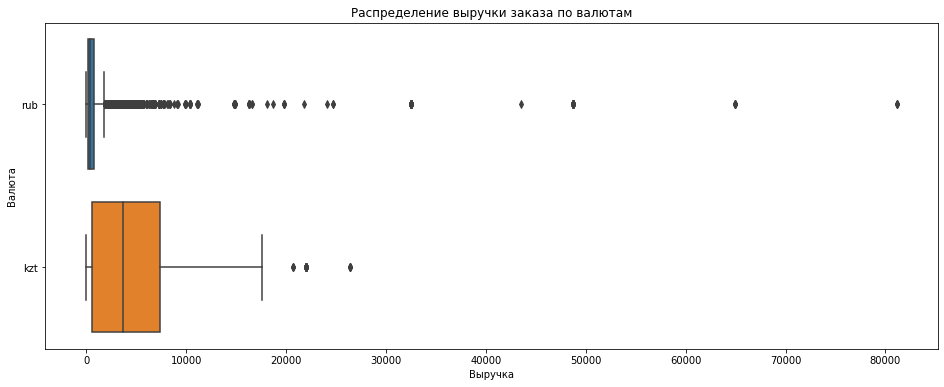

In [15]:
# Создаем визуализацию "ящик с усами"
plt.figure(figsize=(16, 6))

sns.boxplot(data=purchases,
            y='currency_code',
            x='revenue')

plt.title('Распределение выручки заказа по валютам')
plt.xlabel('Выручка')
plt.ylabel('Валюта')

plt.show()

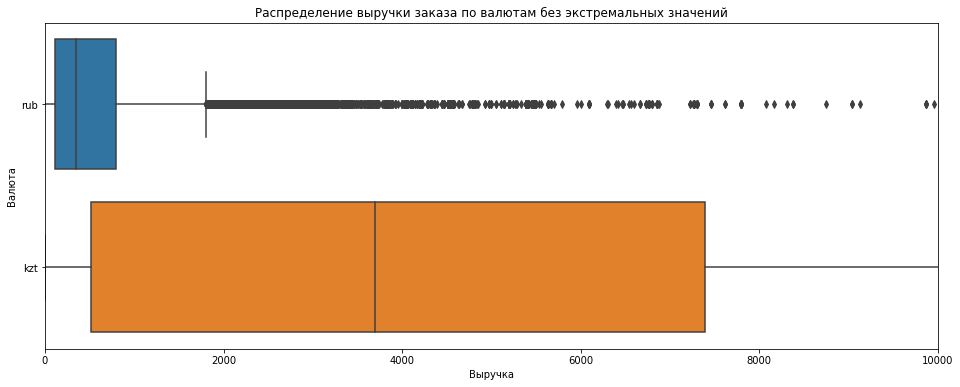

In [16]:
# Ставим ограничение в 10тыс.
plt.figure(figsize=(16, 6))

sns.boxplot(data=purchases,
            y='currency_code',
            x='revenue')

plt.xlim(0, 10000)

plt.title('Распределение выручки заказа по валютам без экстремальных значений')
plt.xlabel('Выручка')
plt.ylabel('Валюта')

plt.show()

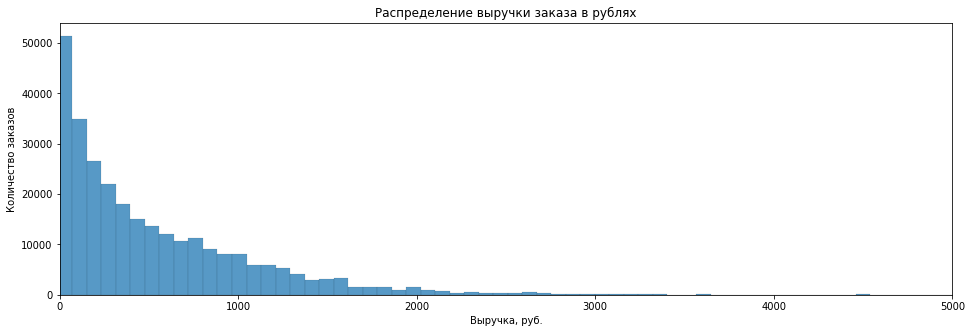

In [17]:
# Сооздаем гистограмму выручки в рублях
plt.figure(figsize=(16, 5))

sns.histplot(data=purchases[purchases['currency_code'] == 'rub'],
             x='revenue',
             bins=1000)

plt.xlim(0, 5000)

plt.title('Распределение выручки заказа в рублях')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')

plt.show()

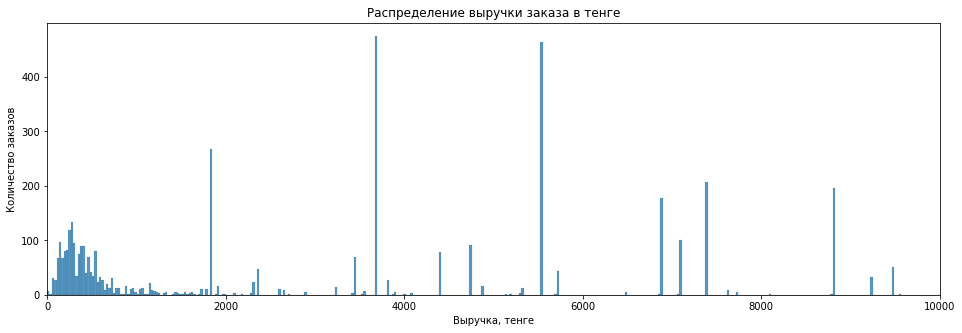

In [18]:
# Создаем гистограмму выручки в тенге
plt.figure(figsize=(16, 5))

sns.histplot(data=purchases[purchases['currency_code'] == 'kzt'],
             x='revenue',
             bins=1000)

plt.xlim(0, 10000)

plt.title('Распределение выручки заказа в тенге')
plt.xlabel('Выручка, тенге')
plt.ylabel('Количество заказов')

plt.show()

In [19]:
# Сохраняем исходный размер до удаления дубликатов и выбросов
initial_rows = purchases.shape[0]

In [20]:
# Считаем процентиль
revenue_percentiles = purchases.groupby('currency_code')['revenue'].quantile(0.99)

display(revenue_percentiles)

currency_code
kzt    17617.2400
rub     2569.5942
Name: revenue, dtype: float64

In [21]:
# Фильтруем значения выше 99-го перцентиля
purchases = purchases[((purchases['currency_code'] == 'rub') & (purchases['revenue'] <= revenue_percentiles['rub']))
                      |((purchases['currency_code'] == 'kzt') & (purchases['revenue'] <= revenue_percentiles['kzt']))].copy()

print('Размер датасета после фильтрации:', purchases.shape)

Размер датасета после фильтрации: (287962, 14)


[Назад к содержанию](#step1)

<a id="step8"></a>
#### 2.4. Проверка явных и неявных дубликатов

In [22]:
print('Количество явных дубликатов в purchases:', purchases.duplicated().sum())
print('Количество явных дубликатов в events:', events.duplicated().sum())
print('Количество явных дубликатов в tenge_rate:', tenge_rate.duplicated().sum())

Количество явных дубликатов в purchases: 0
Количество явных дубликатов в events: 0
Количество явных дубликатов в tenge_rate: 0


In [23]:
print('Количество дубликатов order_id:', purchases['order_id'].duplicated().sum())
print('Количество дубликатов event_id в events:', events['event_id'].duplicated().sum())

Количество дубликатов order_id: 0
Количество дубликатов event_id в events: 0


In [24]:
columns_without_order_id = [
    'user_id',
    'created_dt_msk',
    'created_ts_msk',
    'event_id',
    'cinema_circuit',
    'age_limit',
    'currency_code',
    'device_type_canonical',
    'revenue',
    'service_name',
    'tickets_count',
    'total'
]

implicit_duplicates = purchases[purchases.duplicated(subset=columns_without_order_id,keep=False)
                    ].sort_values(by=['user_id', 'created_ts_msk', 'event_id'])

print('Количество строк с возможными неявными дубликатами:', implicit_duplicates.shape[0])

display(implicit_duplicates.head(10))

Количество строк с возможными неявными дубликатами: 75


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,11.0
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,0.0
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,6016.94,32.0
53717,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,6016.94,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
68214,3326185,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,Билеты без проблем,2,1008.14,7.0
68215,3326272,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,Билеты без проблем,2,1008.14,0.0


In [25]:
duplicates_to_remove = purchases.duplicated(subset=columns_without_order_id,keep='first').sum()

print('Количество строк для удаления:', duplicates_to_remove)

Количество строк для удаления: 39


In [26]:
purchases = purchases.drop_duplicates(subset=columns_without_order_id).copy()

print('Размер датасета после удаления неявных дубликатов:', purchases.shape)

Размер датасета после удаления неявных дубликатов: (287923, 14)


In [27]:
# Итоговая статистика по предобработке
# initial_rows был сохранен перед удалением выбросов
final_rows = purchases.shape[0]

removed_rows = initial_rows - final_rows
removed_share = removed_rows / initial_rows * 100

print('Исходное количество строк:', initial_rows)
print('Количество строк после предобработки:', final_rows)
print('Удалено строк:', removed_rows)
print('Доля удалённых строк:', round(removed_share, 2), '%')

Исходное количество строк: 290849
Количество строк после предобработки: 287923
Удалено строк: 2926
Доля удалённых строк: 1.01 %


[Назад к содержанию](#step1)

<a id="step9"></a>
#### 2.5. Преобразование типов данных

In [28]:
# Преобразуем даты и время в формат datetime
for column in ['created_dt_msk', 'created_ts_msk']:
    purchases[column] = pd.to_datetime(purchases[column])

tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])

In [29]:
# Проверяем
print('Типы данных в purchases:')
display(purchases[['created_dt_msk', 'created_ts_msk']].dtypes)

print('Тип данных в tenge_rate:')
display(tenge_rate[['data']].dtypes)

Типы данных в purchases:


created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object

Тип данных в tenge_rate:


data    datetime64[ns]
dtype: object

[Назад к содержанию](#step1)

<a id="step10"></a>
#### 2.6. Создание новых признаков

In [30]:
# Объединение таблиц purchases и tenge_rate
purchases = purchases.merge(tenge_rate,left_on='created_dt_msk', right_on='data', how='left')

display(purchases.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN,2024-08-20,100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN,2024-07-23,100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0,2024-10-06,100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN,2024-07-13,100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0,2024-10-04,100,19.6648,kzt


In [31]:
# Проверим, что для всех заказов в тенге нашелся курс
print(
    'Количество заказов в тенге без информации о курсе:',
    purchases[purchases['currency_code'] == 'kzt']['curs'].isna().sum()
)

Количество заказов в тенге без информации о курсе: 0


In [32]:
# Создаем столбец с выручкой в рублях
purchases['revenue_rub'] = purchases['revenue']

# Переводим выручку из тенге в рубли
purchases.loc[
    purchases['currency_code'] == 'kzt',
    'revenue_rub'
] = (
    purchases['revenue']
    / purchases['nominal']
    * purchases['curs']
)

In [33]:
# Выручка с продажи одного билета
purchases['one_ticket_revenue_rub'] = (
    purchases['revenue_rub'] / purchases['tickets_count']
)

In [34]:
# Выделяем месяц заказа
purchases['month'] = purchases['created_dt_msk'].dt.month

In [35]:
purchases['season'] = ''

purchases.loc[purchases['month'].isin([12, 1, 2]),'season'] = 'зима'

purchases.loc[purchases['month'].isin([3, 4, 5]),'season'] = 'весна'

purchases.loc[purchases['month'].isin([6, 7, 8]),'season'] = 'лето'

purchases.loc[purchases['month'].isin([9, 10, 11]),'season'] = 'осень'

In [36]:
# Проверка новых признаков
display(
    purchases[[
            'created_dt_msk',
            'currency_code',
            'revenue',
            'nominal',
            'curs',
            'revenue_rub',
            'tickets_count',
            'one_ticket_revenue_rub',
            'month',
            'season'
        ]].head())

,created_dt_msk,currency_code,revenue,nominal,curs,revenue_rub,tickets_count,one_ticket_revenue_rub,month,season
0,2024-08-20,rub,1521.94,100,18.6972,1521.94,4,380.4850,8,лето
1,2024-07-23,rub,289.45,100,18.3419,289.45,2,144.7250,7,лето
2,2024-10-06,rub,1258.57,100,19.6475,1258.57,4,314.6425,10,осень
3,2024-07-13,rub,8.49,100,18.5010,8.49,2,4.2450,7,лето
4,2024-10-04,rub,1390.41,100,19.6648,1390.41,3,463.4700,10,осень


In [37]:
# Создаем единый датафрейм
purchases = purchases.merge(events,on='event_id',how='left')

print('Размер объединённого датасета:', purchases.shape)

Размер объединённого датасета: (287923, 32)


In [38]:
# Проверка
print(
    'Количество заказов без информации о мероприятии:',
    purchases['event_name'].isna().sum()
)

Количество заказов без информации о мероприятии: 238


In [39]:
print('Итоговый размер датасета purchases:', purchases.shape)

print(
    'Количество пропусков в revenue_rub:',
    purchases['revenue_rub'].isna().sum()
)

print(
    'Количество пропусков в one_ticket_revenue_rub:',
    purchases['one_ticket_revenue_rub'].isna().sum()
)

print('Месяцы в данных:')
display(purchases['month'].value_counts().sort_index())

print('Сезоны в данных:')
display(purchases['season'].value_counts())

Итоговый размер датасета purchases: (287923, 32)
Количество пропусков в revenue_rub: 0
Количество пропусков в one_ticket_revenue_rub: 0
Месяцы в данных:


6     34343
7     40408
8     44570
9     69331
10    99271
Name: month, dtype: int64

Сезоны в данных:


осень    168602
лето     119321
Name: season, dtype: int64

[Назад к содержанию](#step1)

<a id="step11"></a>
#### 2.7. Промежуточные выводы

В ходе предобработки были изучены и подготовлены данные о заказах билетов, мероприятиях и курсе казахстанского тенге к российскому рублю за период с 1 июня по 31 октября 2024 года. 

Проверка пропусков показала, что данные соответствуют условию задачи. Пропуски присутствуют только в столбце `days_since_prev` датасета `purchases`: 21 940 значений. Они означают отсутствие данных о предыдущей покупке пользователя и не требуют заполнения. В остальных столбцах всех трех датасетов пропусков не обнаружено.  

Проверка дат подтвердила, что данные о заказах охватывают весь заявленный период: с 1 июня по 31 октября 2024 года.

Категориальные значения выглядят корректными. В заказах представлены две валюты - российский рубль и казахстанский тенге, а также два типа устройств - мобильные и стационарные. Значение `нет` в столбце `cinema_circuit` не является пропуском, а означает, что сеть кинотеатров неприменима к заказу. В таблице мероприятий не обнаружено ошибок в основных категориях.

Распределения выручки в рублях и тенге имеют правостороннюю асимметрию: большая часть заказов относится к небольшим значениям выручки, а дорогие заказы встречаются существенно реже. Для снижения влияния аномально высоких значений были исключены заказы с выручкой выше 99-го перцентиля отдельно по каждой валюте. Верхний допустимый порог составил 2 569,59 рубля для заказов в рублях и 17 617,24 тенге для заказов в тенге. После фильтрации было удалено 2 887 строк.

В данных обнаружен 381 заказ с отрицательной выручкой, что составляет 0,132% исходного датасета. Такие значения могут быть связаны с возвратами билетов или корректировками оплаты. Так как отдельного признака возврата в данных нет, эти заказы не удалялись. При дальнейшем анализе выручки необходимо учитывать их возможное влияние на результаты.

Явные дубликаты в датасетах не обнаружены. Идентификаторы заказов `order_id` и мероприятий `event_id` уникальны.
Для поиска неявных дубликатов идентификатор заказа `order_id` не учитывался, так как он является техническим уникальным идентификатором. Также при проверке не использовался столбец `days_since_prev`.

Заказ считался потенциальным неявным дубликатом, если совпадали пользователь, дата и точное время оформления, мероприятие, сеть кинотеатров, возрастное ограничение, валюта, тип устройства, выручка, итоговая сумма заказа, билетный оператор и количество билетов. Совпадение всех этих характеристик при разных значениях `order_id` с высокой вероятностью указывает на повторную запись одного бронирования, а не на независимые заказы. Было найдено 75 строк, входящих в группы возможных неявных дубликатов. После сохранения одной записи из каждой группы удалено 39 повторяющихся строк.

Столбцы `created_dt_msk`, `created_ts_msk` и `data` были преобразованы в формат даты и времени. Это позволило сопоставить дату заказа с курсом тенге и создать дополнительные признаки.

Выручка заказов в тенге была приведена к российским рублям по курсу на дату оформления заказа. Для всех заказов в тенге курс был успешно найден. 

Были созданы новые признаки:
- `revenue_rub` - выручка заказа в российских рублях;  
- `one_ticket_revenue_rub` - выручка от продажи одного билета в российских рублях;  
- `month` - месяц оформления заказа;  
- `season` - сезон оформления заказа. 

После объединения заказов с данными о мероприятиях для 238 заказов не нашлась информация о соответствующем мероприятии. Это составляет менее 0,1% всех записей. Такие заказы были сохранены, поскольку содержат информацию о выручке, пользователе и параметрах заказа, но их нельзя будет использовать в анализе по типу мероприятия, региону, городу или площадке.

В результате предобработки размер основного датасета уменьшился с 290 849 до 287 923 строк. Было исключено 2 926 строк, что составляет около 1,01% исходных данных. Итоговый датасет содержит 32 столбца и подготовлен для дальнейшего исследовательского анализа.

[Назад к содержанию](#step1)

<a id="step12"></a>
### 3. Исследовательский анализ данных  
#### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

In [40]:
# Количество заказов по месяцам
orders_by_month = (purchases.groupby('month', as_index=False)['order_id'].count().rename(columns={'order_id': 'orders_count'}))

display(orders_by_month)

,month,orders_count
0,6,34343
1,7,40408
2,8,44570
3,9,69331
4,10,99271


In [41]:
# Количество заказов по сезонам
orders_by_season = (purchases.groupby('season', as_index=False)['order_id'].count()
                    .rename(columns={'order_id': 'orders_count'}))

display(orders_by_season)

,season,orders_count
0,лето,119321
1,осень,168602


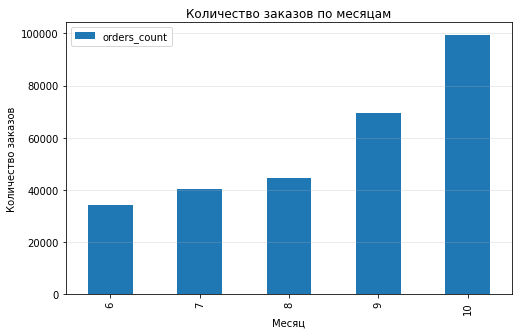

In [42]:
# Визуализация: заказы по месяцам
orders_by_month.plot(x='month',
                     y='orders_count',
                     kind='bar',
                     figsize=(8, 5))

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.grid(axis='y', alpha=0.3)
plt.show();

In [43]:
# Функция для расчета долей внутри сезона
def calc_share(df, group_cols, value_col='order_id'):
    table = (
        df
        .groupby(['season'] + group_cols, as_index=False)[value_col]
        .count()
        .rename(columns={value_col: 'count'})
    )
    
    pivot = table.pivot(index=group_cols[0], columns='season', values='count').reset_index()
    
    # Считаем доли
    for season in ['лето', 'осень']:
        pivot[f'{season}_share'] = pivot[season] / pivot[season].sum()
    
    pivot['всего'] = pivot['лето'] + pivot['осень']
    
    return pivot

In [44]:
# Тип мероприятия
pivot_type = calc_share(purchases, ['event_type_main'])
print("Тип мероприятия:")
display(pivot_type)

# Тип устройства
pivot_device = calc_share(purchases, ['device_type_canonical'])
print("\nТип устройства:")
display(pivot_device)

# Возраст
pivot_age = calc_share(purchases, ['age_limit'])
print("\nВозрастное ограничение:")
display(pivot_age)

Тип мероприятия:


season,event_type_main,лето,осень,лето_share,осень_share,всего
0,выставки,2416,2436,0.020285,0.014450,4852
1,другое,32367,33225,0.271752,0.197087,65592
2,концерты,50755,62691,0.426137,0.371877,113446
3,спорт,3006,18881,0.025238,0.112000,21887
4,стендап,6346,6923,0.053281,0.041067,13269
5,театр,23942,42733,0.201016,0.253488,66675
6,ёлки,273,1691,0.002292,0.010031,1964



Тип устройства:


season,device_type_canonical,лето,осень,лето_share,осень_share,всего
0,desktop,23102,34303,0.193612,0.203455,57405
1,mobile,96219,134299,0.806388,0.796545,230518



Возрастное ограничение:


season,age_limit,лето,осень,лето_share,осень_share,всего
0,0,21402,39828,0.179365,0.236225,61230
1,6,21679,29724,0.181686,0.176297,51403
2,12,24520,37232,0.205496,0.220828,61752
3,16,33777,44216,0.283077,0.262251,77993
4,18,17943,17602,0.150376,0.104400,35545


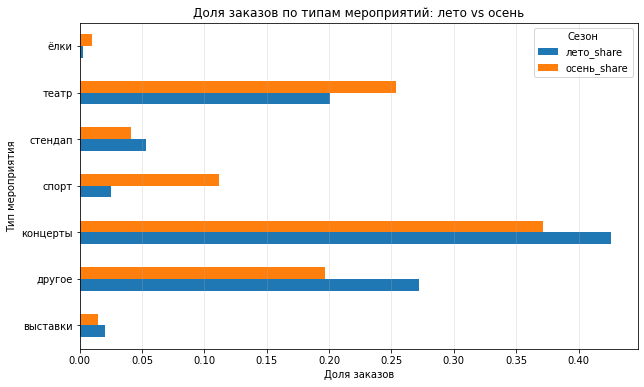

In [45]:
# Тип мероприятия
pivot_type.plot(x='event_type_main',
                y=['лето_share', 'осень_share'],
                kind='barh',
                figsize=(10, 6))

plt.xlabel('Доля заказов')
plt.ylabel('Тип мероприятия')
plt.title('Доля заказов по типам мероприятий: лето vs осень')
plt.legend(title='Сезон')
plt.grid(axis='x', alpha=0.3)
plt.show();

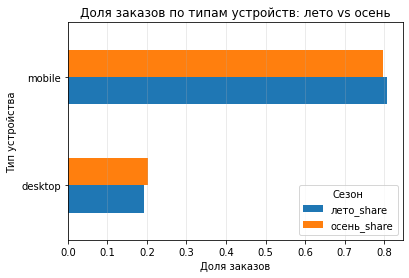

In [46]:
# Тип устройства
pivot_device.plot(x='device_type_canonical',
                  y=['лето_share', 'осень_share'],
                  kind='barh',
                  figsize=(6, 4))

plt.xlabel('Доля заказов')
plt.ylabel('Тип устройства')
plt.title('Доля заказов по типам устройств: лето vs осень')
plt.legend(title='Сезон')
plt.grid(axis='x', alpha=0.3)
plt.show();

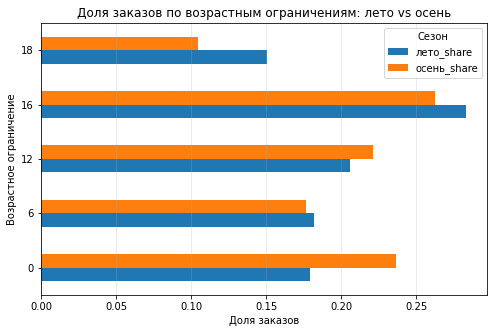

In [47]:
# Возраст
pivot_age.plot(x='age_limit',
               y=['лето_share', 'осень_share'],
               kind='barh',
               figsize=(8, 5))

plt.xlabel('Доля заказов')
plt.ylabel('Возрастное ограничение')
plt.title('Доля заказов по возрастным ограничениям: лето vs осень')
plt.legend(title='Сезон')
plt.grid(axis='x', alpha=0.3)
plt.show();

In [48]:
# Средняя выручка с одного билета по типам мероприятий и сезонам
purchases['price_per_ticket'] = purchases['revenue'] / purchases['tickets_count']

avg_price_by_type_season = (purchases.groupby(['season', 'event_type_main'], as_index=False)['price_per_ticket'].mean()
                            .rename(columns={'price_per_ticket': 'avg_price'}))

# Сводная таблица
pivot_price_type = avg_price_by_type_season.pivot(index='event_type_main',columns='season',values='avg_price').reset_index()

# Относительное изменение: (осень - лето) / лето
pivot_price_type['change'] = (pivot_price_type['осень'] - pivot_price_type['лето']) / pivot_price_type['лето']

print("Средняя выручка с одного билета по типам мероприятий:")
display(pivot_price_type)

Средняя выручка с одного билета по типам мероприятий:


season,event_type_main,лето,осень,change
0,выставки,86.416198,90.603610,0.048456
1,другое,81.977834,80.452747,-0.018604
2,концерты,430.598465,278.832537,-0.352453
3,спорт,55.172065,53.926431,-0.022577
4,стендап,219.073164,231.124973,0.055013
5,театр,214.181610,175.977088,-0.178374
6,ёлки,271.436176,229.585589,-0.154182


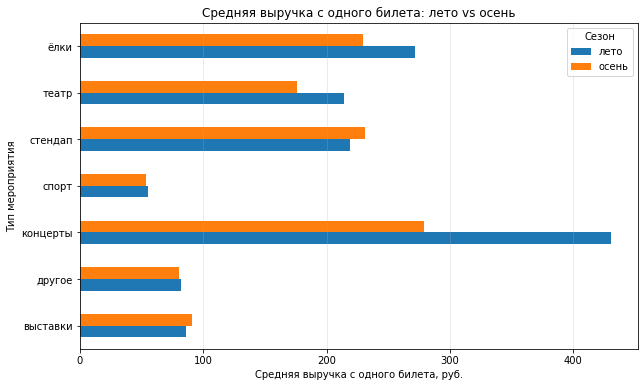

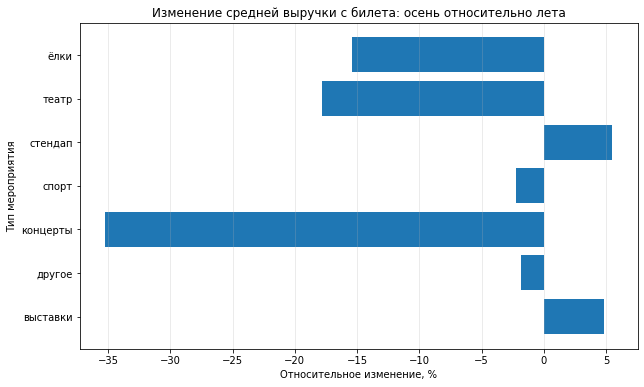

In [49]:
# Визуализация: средняя цена билета по типам мероприятий (лето vs осень)
pivot_price_type.plot(x='event_type_main',
                      y=['лето', 'осень'],
                      kind='barh',
                      figsize=(10, 6))

plt.xlabel('Средняя выручка с одного билета, руб.')
plt.ylabel('Тип мероприятия')
plt.title('Средняя выручка с одного билета: лето vs осень')
plt.legend(title='Сезон')

plt.grid(axis='x', alpha=0.3)
plt.show();

# Визуализация: относительное изменение (%)
plt.figure(figsize=(10, 6))

plt.barh(pivot_price_type['event_type_main'],
         pivot_price_type['change'] * 100)

plt.xlabel('Относительное изменение, %')
plt.ylabel('Тип мероприятия')
plt.title('Изменение средней выручки с билета: осень относительно лета')

plt.grid(axis='x', alpha=0.3)
plt.show();

##### Промежуточный вывод: 

- Динамика заказов:  
Количество заказов растет от июня (34 343) к октябрю (99 271). Осенью заказов значительно больше (168 602), чем летом (119 321), несмотря на то, что отчетный период включает всего два месяца, сезонность подтверждается.

- Тип мероприятия:  
Доля концертов снижается с 42.6% до 37.2%, но остается лидером. Доля театра растет с 20.1% до 25.3%, спорта — с 2.5% до 11.2%. Категория «другое» снижает долю с 27.2% до 19.7%.

- Тип устройства:  
Структура стабильна: mobile доминирует (80.6% летом, 79.7% осенью), desktop незначительно растет (с 19.4% до 20.3%).

- Возраст:   
Доля 0+ растет (с 17.9% до 23.6%), 18+ падает (с 15.0% до 10.4%) - осенью спрос смещается в сторону семейных мероприятий.

- Средняя цена билета:  
Концерты: −35.2% (с 430.6 до 278.8 руб.), театр: −17.8%, елки: −15.4%. Выставки (+4.8%) и стендап (+5.5%) дорожают.

- Итог:   
Осенью заказов больше, растет доля театра, спорта и семейных мероприятий, средняя цена билета по большинству типов снижается.

[Назад к содержанию](#step1)

<a id="step13"></a>
#### 3.2. Осенняя активность пользователей 

In [50]:
# Фильтруем данные по осенним месяцам (сентябрь и октябрь)
autumn = purchases[purchases['month'].isin([9, 10])].copy()

# Сводная таблица по дням
daily_stats = (autumn.groupby('created_dt_msk', as_index=False).agg(orders_count=('order_id', 'count'),
                                                                    dau=('user_id', 'nunique'),
                                                                    revenue_sum=('revenue', 'sum'),
                                                                    tickets_count=('tickets_count', 'sum')))

# Среднее число заказов на пользователя
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']

# Средняя стоимость одного билета
daily_stats['avg_price_per_ticket'] = daily_stats['revenue_sum'] / daily_stats['tickets_count']

display(daily_stats.head())

,created_dt_msk,orders_count,dau,revenue_sum,tickets_count,orders_per_user,avg_price_per_ticket
0,2024-09-01,1327,564,733571.82,3718,2.352837,197.302803
1,2024-09-02,1380,574,777955.47,3704,2.404181,210.031174
2,2024-09-03,5111,778,1229176.90,15290,6.569409,80.390903
3,2024-09-04,1773,685,950093.25,4802,2.588321,197.853655
4,2024-09-05,1944,739,1106281.15,5214,2.630582,212.175134


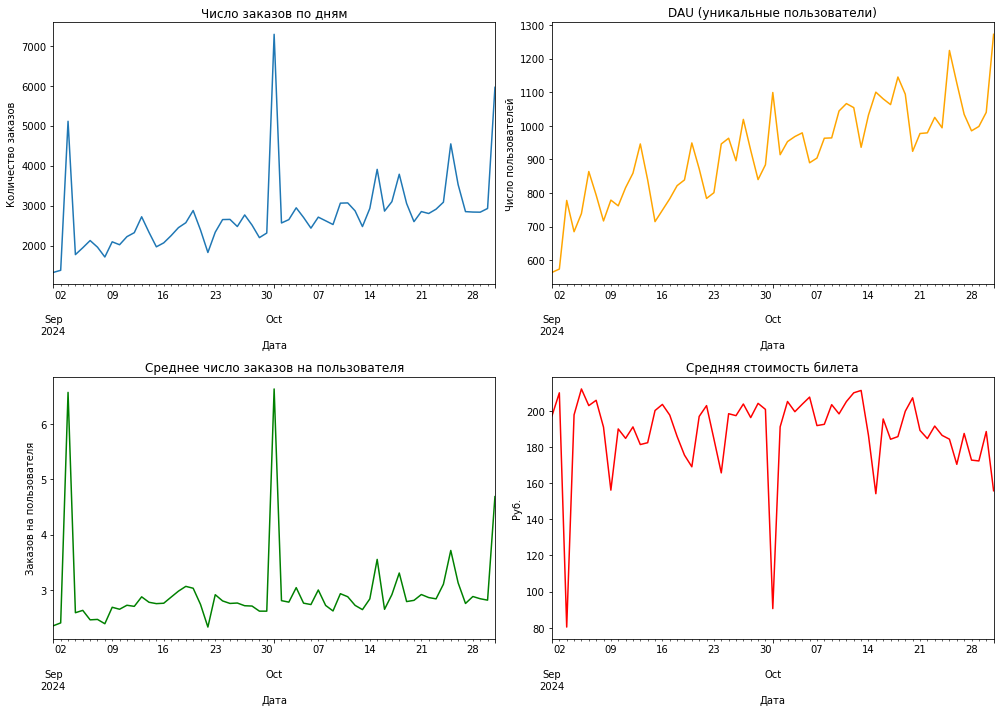

In [51]:
# График: число заказов и DAU
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Число заказов
daily_stats.plot(x='created_dt_msk', y='orders_count', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Число заказов по дням')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество заказов')

# DAU
daily_stats.plot(x='created_dt_msk', y='dau', ax=axes[0, 1], legend=False, color='orange')
axes[0, 1].set_title('DAU (уникальные пользователи)')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Число пользователей')

# Заказы на пользователя
daily_stats.plot(x='created_dt_msk', y='orders_per_user', ax=axes[1, 0], legend=False, color='green')
axes[1, 0].set_title('Среднее число заказов на пользователя')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Заказов на пользователя')

# Средняя цена билета
daily_stats.plot(x='created_dt_msk', y='avg_price_per_ticket', ax=axes[1, 1], legend=False, color='red')
axes[1, 1].set_title('Средняя стоимость билета')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Руб.')

plt.tight_layout()
plt.show();

In [52]:
# Добавляем день недели
autumn['day_of_week'] = pd.to_datetime(autumn['created_dt_msk']).dt.dayofweek
autumn['day_name'] = pd.to_datetime(autumn['created_dt_msk']).dt.day_name()

# Тип дня: будни (0-4) vs выходные (5-6)
autumn['day_type'] = autumn['day_of_week'].apply(lambda x: 'выходные' if x >= 5 else 'будни')

# Число заказов по дням недели
orders_by_day = (autumn.groupby('day_name', as_index=False)['order_id'].count().rename(columns={'order_id': 'orders_count'}))

# Порядок дней
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day['day_num'] = orders_by_day['day_name'].map({d: i for i, d in enumerate(day_order)})
orders_by_day = orders_by_day.sort_values('day_num')

display(orders_by_day)

,day_name,orders_count,day_num
1,Monday,21515,0
5,Tuesday,31479,1
6,Wednesday,22888,2
4,Thursday,27168,3
0,Friday,24828,4
2,Saturday,21335,5
3,Sunday,19389,6


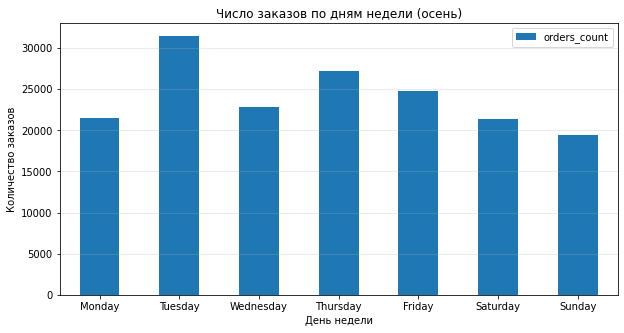

In [53]:
# Визуализация
orders_by_day.plot(x='day_name',
                   y='orders_count',
                   kind='bar',
                   figsize=(10, 5))

plt.title('Число заказов по дням недели (осень)')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show();

In [54]:
# Будни vs выходные
orders_by_day_type = ( autumn.groupby('day_type', as_index=False)['order_id'].count()
                      .rename(columns={'order_id': 'orders_count'}))

display(orders_by_day_type)

,day_type,orders_count
0,будни,127878
1,выходные,40724


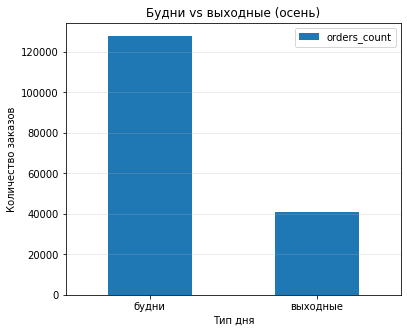

In [55]:
# Визуализация
orders_by_day_type.plot(x='day_type',
                        y='orders_count',
                        kind='bar',
                        figsize=(6, 5))

plt.title('Будни vs выходные (осень)')
plt.xlabel('Тип дня')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show();

##### Промежуточный вывод: 
- Динамика по дням:  
Число заказов и DAU сильно варьируются по дням: наблюдаются пики (например, 5111 заказов и 778 пользователей в начале сентября, в начале октября также наблюдается высокий рост) и спады. Среднее число заказов на пользователя колеблется от 2,3 до 6,6, что указывает на разную интенсивность покупок в разные дни. Средняя стоимость билета также нестабильна (от 80 до 212 руб.).
- Недельная цикличность:  
Наибольшая активность во вторник (31 479 заказов), наименьшая - в воскресенье (19 389 заказов).
Будни значительно активнее выходных: 127 878 заказов (76%) против 40 724 (24%).
Пик приходится на середину недели (вторник–четверг), к выходным активность снижается.
- Итог:  
Осенью пользовательская активность нестабильна по дням с выраженной недельной цикличностью: будни значительно активнее выходных, пик - во вторник. Это может указывать на то, что пользователи чаще покупают билеты в рабочие дни.

[Назад к содержанию](#step1)

<a id="step14"></a>
#### 3.3. Популярные события и партнеры

In [56]:
# Объединяем заказы с мероприятиями по event_id
orders_events = purchases.merge(events[['event_id', 'region_name', 'city_name']]
                                .drop_duplicates(),on='event_id', how='left',suffixes=('', '_event'))

# Количество уникальных мероприятий и заказов по регионам
region_stats = (orders_events.groupby('region_name', as_index=False).agg(events_count=('event_id', 'nunique'),
                                                                         orders_count=('order_id', 'count'),
                                                                         revenue_sum=('revenue', 'sum'))
                                                                    .sort_values('orders_count', ascending=False))

# Доли
region_stats['events_share'] = region_stats['events_count'] / region_stats['events_count'].sum()
region_stats['orders_share'] = region_stats['orders_count'] / region_stats['orders_count'].sum()
region_stats['revenue_share'] = region_stats['revenue_sum'] / region_stats['revenue_sum'].sum()

print("Топ-10 регионов по числу заказов:")
display(region_stats.head(10))

Топ-10 регионов по числу заказов:


,region_name,events_count,orders_count,revenue_sum,events_share,orders_share,revenue_share
23,Каменевский регион,5935,89662,5.600064e+07,0.265441,0.311667,0.331512
60,Североярская область,3800,43737,2.210208e+07,0.169954,0.152031,0.130840
77,Широковская область,1232,16169,8.628101e+06,0.055101,0.056204,0.051077
42,Медовская область,504,13892,2.927650e+06,0.022541,0.048289,0.017331
45,Озернинский край,349,10348,9.407522e+06,0.015609,0.035970,0.055691
57,Светополянский округ,1075,7501,3.037787e+06,0.048079,0.026074,0.017983
41,Малиновоярский округ,165,6314,5.089834e+06,0.007380,0.021948,0.030131
64,Солнечноземская область,522,6278,1.180949e+06,0.023346,0.021822,0.006991
52,Речиновская область,702,6266,2.630250e+06,0.031397,0.021781,0.015571
78,Яблоневская область,535,6123,3.505459e+06,0.023928,0.021284,0.020752


In [57]:
# Статистика по партнерам
partner_stats = (purchases.groupby('service_name', as_index=False).agg(events_count=('event_id', 'nunique'),
                                                                       orders_count=('order_id', 'count'),
                                                                       revenue_sum=('revenue', 'sum'))
                                                                  .sort_values('revenue_sum', ascending=False))

# Доли
partner_stats['events_share'] = partner_stats['events_count'] / partner_stats['events_count'].sum()
partner_stats['orders_share'] = partner_stats['orders_count'] / partner_stats['orders_count'].sum()
partner_stats['revenue_share'] = partner_stats['revenue_sum'] / partner_stats['revenue_sum'].sum()

print("Топ-10 партнеров по выручке:")
display(partner_stats.head(10))

Топ-10 партнеров по выручке:


,service_name,events_count,orders_count,revenue_sum,events_share,orders_share,revenue_share
24,Мой билет,1302,34443,3.938912e+07,0.053352,0.119626,0.233171
3,Билеты без проблем,4255,63020,2.642867e+07,0.174357,0.218878,0.156449
25,Облачко,2335,26402,1.858861e+07,0.095681,0.091698,0.110039
21,Лови билет!,4869,40800,1.666898e+07,0.199516,0.141705,0.098675
8,Весь в билетах,855,16409,1.649378e+07,0.035035,0.056991,0.097638
5,Билеты в руки,3536,40300,1.319627e+07,0.144894,0.139968,0.078118
19,Край билетов,252,6109,6.405689e+06,0.010326,0.021217,0.037920
26,Прачечная,1026,10222,4.746811e+06,0.042042,0.035503,0.028100
13,Дом культуры,272,4412,4.358656e+06,0.011146,0.015324,0.025802
35,Яблоко,714,5004,3.868337e+06,0.029257,0.017380,0.022899


##### Промежуточный вывод: 

- Регионы:  
Топ-3 региона (Каменевский регион, Североярская область, Широковская область) дают 52% всех заказов.
Каменевский регион - явный лидер: 26.5% мероприятий, 31.2% заказов и 33.2% выручки.
Топ-10 регионов охватывают существенную часть заказов, но распределение неравномерное, есть явные лидеры.
- Партнеры:  
Топ-3 партнера («Мой билет», «Билеты без проблем», «Облачко») дают около 50% выручки.
«Мой билет» - лидер по выручке (23.3%), хотя обрабатывает только 12% заказов — значит, средняя цена билета выше.
«Билеты без проблем» - лидер по количеству заказов (21.9%) и мероприятий (17.4%).
- Итог:  
Существуют явные лидеры среди регионов и партнеров. Каменевский регион доминирует по всем метрикам, среди партнеров - «Мой билет» и «Билеты без проблем». Распределение неравномерное: топ-10 регионов и партнеров обеспечивают большую часть заказов и выручки.

[Назад к содержанию](#step1)

<a id="step15"></a>
### 4. Статистический анализ данных  
#### 4.1. Проверка гипотезы о среднем количестве заказов на пользователя

Формулируем гипотезу:
- Нулевая гипотеза **𝐻0**:μ_mobile ≤ μ_desktop  
Среднее количество заказов на одного пользователя мобильных устройств не больше, чем у пользователей стационарных устройств.

- Альтернативная гипотеза **𝐻1**: μ_mobile > μ_desktop  
Среднее количество заказов на одного пользователя мобильных устройств больше, чем у пользователей стационарных устройств, и это различие статистически значимо.

Для проверки гипотезы используем тест Манна-Уитни, т.к. он не требует нормальности распределения, наши данные содержат много выбросов, работает с любыми распределениями.

In [58]:
# Фильтруем данные по осени
autumn = purchases[purchases['month'].isin([9, 10])].copy()

# Количество заказов на пользователя по типам устройств
orders_per_user = (autumn.groupby(['user_id', 'device_type_canonical'], as_index=False)['order_id'].count()
                   .rename(columns={'order_id': 'orders_count'}))

mobile_orders = orders_per_user[orders_per_user['device_type_canonical'] == 'mobile']['orders_count']
desktop_orders = orders_per_user[orders_per_user['device_type_canonical'] == 'desktop']['orders_count']

alpha = 0.05

mw_test = mannwhitneyu(
    mobile_orders,  # Выборка значений метрики для группы mobile
    desktop_orders,  # Выборка значений метрики для группы desktop
    alternative='greater'  # Альтернативная гипотеза: Dist(mobile) > Dist(desktop)
)

print(f"Mobile: пользователей={len(mobile_orders)}, среднее заказов={mobile_orders.mean()}")
print(f"Desktop: пользователей={len(desktop_orders)}, среднее заказов={desktop_orders.mean()}")
print(f"p-value={mw_test.pvalue}")

if mw_test.pvalue > alpha:
    print(f'p-value={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Среднее количество заказов у mobile и desktop не различается.')
else:
    print(f'p-value={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Пользователи mobile делают статистически больше заказов.')

Mobile: пользователей=14190, среднее заказов=9.464341085271318
Desktop: пользователей=4869, среднее заказов=7.04518381597864
p-value=3.459853111231813e-07
p-value=3.459853111231813e-07 < 0.05
Нулевая гипотеза не находит подтверждения! Пользователи mobile делают статистически больше заказов.


##### Гипотеза 1: Среднее количество заказов на пользователя

Mobile: 14190 пользователей, среднее заказов = 9.464341085271318.

Desktop: 4869 пользователей, среднее заказов = 7.04518381597864.

p-value = 3.459853111231813e-07 < 0.05.

Вывод: Нулевая гипотеза отвергается. Пользователи мобильных устройств делают больше заказов на одного пользователя, чем пользователи стационарных устройств.

[Назад к содержанию](#step1)

<a id="step16"></a>
#### 4.2. Проверка гипотезы о среднем времени между заказами

 Формулируем гипотезу:
- Нулевая гипотеза **𝐻0**: μ_mobile ≤ μ_desktop    
Среднее время между заказами у пользователей мобильных устройств не больше, чем у пользователей стационарных устройств.  
- Альтернативная гипотеза **𝐻H1**: μ_mobile > μ_desktop  
Среднее время между заказами у пользователей мобильных устройств больше, и это различие статистически значимо.


In [59]:
# Время между заказами по типам устройств
days_since_prev = autumn[autumn['days_since_prev'].notna()][['device_type_canonical', 'days_since_prev']]

mobile_days = days_since_prev[days_since_prev['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_days = days_since_prev[days_since_prev['device_type_canonical'] == 'desktop']['days_since_prev']

alpha = 0.05

mw_test = mannwhitneyu(
    mobile_days,  # Выборка значений метрики для группы mobile
    desktop_days,  # Выборка значений метрики для группы desktop
    alternative='greater'  # Альтернативная гипотеза: Dist(mobile) > Dist(desktop)
)

print(f"Mobile: записей={len(mobile_days)}, среднее дней={mobile_days.mean()}")
print(f"Desktop: записей={len(desktop_days)}, среднее дней={desktop_days.mean()}")
print(f"p-value={mw_test.pvalue}")

if mw_test.pvalue > alpha:
    print(f'p-value={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Среднее время между заказами у mobile и desktop не различается.')
else:
    print(f'p-value={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Время между заказами у mobile статистически больше.')


Mobile: записей=127315, среднее дней=3.7792875937634998
Desktop: записей=32945, среднее дней=3.0253756260434055
p-value=2.8111163917873434e-92
p-value=2.8111163917873434e-92 < 0.05
Нулевая гипотеза не находит подтверждения! Время между заказами у mobile статистически больше.


##### Гипотеза 2: Среднее время между заказами

Mobile: 127315 записей, среднее время между заказами = 3.7792875937634998 дней.

Desktop: 32945 записей, среднее время между заказами = 3.0253756260434055 дней.

p-value = 2.8111163917873434e-92 < 0.05.

Вывод: Нулевая гипотеза отвергается. Время между заказами у пользователей мобильных устройств больше, чем у пользователей стационарных устройств. Это означает, что пользователи mobile делают заказы реже (с большими интервалами между покупками).

[Назад к содержанию](#step1)

<a id="step17"></a>
#### 4.3. Выводы по проверке гипотез


Первая гипотеза подтвердилась: пользователи мобильных устройств делают больше заказов на одного пользователя (9.46 против 7.05). Вторая гипотеза также подтвердилась: время между заказами у mobile больше (3.78 дней против 3.03 дней), то есть они заказывают реже. Это может означать, что пользователи mobile склонны делать больше заказов за раз, но с большими интервалами между покупками.

[Назад к содержанию](#step1)

<a id="step18"></a>
### 5. Общий вывод и рекомендации

##### 1. Описание данных и предобработка
Для анализа были загружены три датасета:

- `purchases` - 290 849 строк, 14 столбцов: информация о заказах (идентификаторы заказов и пользователей, дата и время заказа, мероприятие, устройство, валюта, выручка, количество билетов, общая сумма заказа).
- `events` - 22 427 строк, 11 столбцов: информация о мероприятиях (название, тип, организатор, регион, город, площадка, city_id).
- `tenge_rate` - 357 строк, 4 столбца: курс тенге к рублю (дата, номинал, курс, обозначение валюты).

**Проверка пропусков**: Пропуски обнаружены только в столбце `days_since_prev датасета purchases` - 21 940 строк, что соответствует условию задачи (отсутствие данных о предыдущей покупке пользователя). В остальных столбцах датасетов пропусков нет.

**Предобработка данных** включала следующие этапы:

- Преобразование дат: Столбцы `created_dt_msk`, `created_ts_msk` и `data` преобразованы в формат даты и времени для корректной работы с временными метками.  
- Проверка категориальных признаков: Изучены все категориальные столбцы на наличие неявных пропусков, ошибок в названиях и дублирующихся категорий. Проблем не выявлено: две валюты (рубль и тенге), два типа устройств (mobile и desktop), значение «нет» в cinema_circuit означает неприменимость сети кинотеатров.  

**Анализ распределений и выбросов**: Изучены распределения выручки (revenue) и количества билетов (tickets_count) отдельно для рублей и тенге. Распределения имеют правостороннюю асимметрию. Для снижения влияния аномально высоких значений исключены заказы с выручкой выше 99-го перцентиля: верхний порог составил 2569.59 руб. и 17617.24 тенге. Удалено 2 887 строк.

**Отрицательная выручка**: Обнаружен 381 заказ с отрицательной выручкой (0.132% датасета), вероятно, связанные с возвратами билетов или корректировками оплаты. Так как отдельного признака возврата нет и их количество мало, эти заказы сохранены.

**Поиск дубликатов**: Явные дубликаты не обнаружены (`order_id` и `event_id` уникальны). Для поиска неявных дубликатов не учитывались `order_id` (технический идентификатор) и `days_since_prev`. Заказ считался дубликатом при совпадении: пользователь, дата и время, мероприятие, сеть кинотеатров, возрастное ограничение, валюта, тип устройства, выручка, итоговая сумма, билетный оператор и количество билетов. Найдено 75 строк в группах дубликатов, удалено 39 повторяющихся записей.

**Приведение валюты**: Выручка заказов в тенге приведена к российским рублям по курсу на дату оформления заказа. Курс найден для всех заказов в тенге.

**Создание новых признаков**:

`revenue_rub` - выручка заказа в российских рублях.
`one_ticket_revenue_rub` - выручка от продажи одного билета в рублях.
`month` - месяц оформления заказа.
`season` - сезон оформления заказа (лето/осень).

**Объединение с мероприятиями**: Данные о заказах объединены с мероприятиями по `event_id`. Для 238 заказов (менее 0,1%) информация о мероприятии не найдена - сохранены для анализа выручки, но не пригодны для анализа по типу мероприятия, региону, городу или площадке.

**Итог предобработки**: Датасет уменьшился с 290 849 до 287 923 строк (удалено 2926 строк, 1.01%). Итоговый датасет содержит 32 столбца и готов для анализа.

##### 2. Основные выводы
**Динамика и сезонность**
- Заказы растут от июня (34 343) к октябрю (99 271). Осенью заказов больше (168 602), чем летом (119 321).
- Концерты лидируют (37.2%), но их доля падает. Растут театр (25.3%) и спорт (11.2%).
- Mobile доминирует (79.7%), desktop - 20,3%.
- Доля 0+ растёт (23.6%), 18+ падает (10.4%) - спрос смещается к семейным мероприятиям.
- Средняя цена билета снижается: концерты -35.2%, театр -17.8%. Выставки (+4.8%) и стендап (+5.5%) дорожают.

**Динамика по дням и недельная цикличность**
Активность нестабильна: пики до 5111 заказов в день, среднее заказов на пользователя - от 2.3 до 6.6.

Будни активнее выходных: 76% заказов против 24%. Пик во вторник (31479), спад в воскресенье (19389).

**Регионы и партнёры**
- Топ-3 региона: Каменевский регион (лидер: 31.2% заказов, 33.2% выручки), Североярская область, Широковская область.  
- Топ-3 партнёра: «Мой билет» (23.3% выручки, 12% заказов - высокая средняя цена), «Билеты без проблем» (21.9% заказов), «Облачко».  

**Гипотезы**: mobile vs desktop
- Количество заказов: Mobile - 9.46 заказов на пользователя, Desktop - 7.05 (p-value = 3.46e-07 < 0.05). Mobile делают больше заказов.   
- Время между заказами: Mobile - 3.78 дней, Desktop - 3.03 дней (p-value = 2.81e-92 < 0.05). Mobile заказывают реже.

**Итог**: Mobile-пользователи делают больше заказов на одного пользователя, но с большими интервалами - склонны к крупным/спланированным покупкам.

##### 3. Рекомендации
- Мобильные устройства: Улучшать UX, внедрить push-уведомления и ремаркетинг для сокращения времени между заказами, программы лояльности за повторные покупки.
- Desktop: Проанализировать причины низкой конверсии, оптимизировать оформление заказа.
- Сезонность: Увеличить маркетинговые бюджеты осенью, акцент на театр, спорт и семейные мероприятия (0+).
- Недельная цикличность: Запускать акции во вторник-четверг (пик активности), специальные предложения в выходные.
- Регионы: Сфокусироваться на топ-10 регионах, особенно Каменевском (треть выручки), разработать локальные стратегии.
- Партнеры: Укрепить работу с топ-3 партнерами, для «Мой билет» - увеличить объем заказов, для «Билеты без проблем» - повысить среднюю цену билета.
- Дальнейшие исследования: Анализ среднего чека по устройствам, когортный анализ LTV, изучение причин возвратов.

[Назад к содержанию](#step1)